<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Air-Quality-_PM-2.5/XAI_Hybrid_PM_2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install river --quiet

In [2]:

import pandas as pd
import numpy as np

from river import metrics, compose, preprocessing

print("River imported successfully")

River imported successfully


In [3]:
path = "/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/final_pm25_dataset.csv"
pm25_df = pd.read_csv(path)

print("Dataset shape:", pm25_df.shape)
pm25_df.head()

Dataset shape: (130003, 16)


,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,humidity,cloud,visibility_km,longitude,temperature_celsius,condition_text,uv_index,wind_mph,precip_mm,gust_mph,wind_degree,air_quality_PM2.5
0,7.1,198.6,2.5,0.2,58,0,16.0,-120.49,16.1,2,1.0,4.3,0.00,10.3,220,6.3
1,25.3,377.2,3.7,1.4,78,37,10.0,-87.22,23.0,32,1.0,3.8,0.28,7.0,240,19.0
2,28.1,460.6,7.7,7.5,94,50,10.0,-89.20,26.0,23,1.0,2.2,0.30,2.8,182,20.4
3,178.1,2243.0,35.0,19.3,88,100,5.0,-90.53,20.0,19,1.0,13.6,0.09,18.1,190,132.0
4,32.1,307.1,0.3,0.2,89,94,10.0,-88.77,26.0,30,1.0,4.3,0.00,6.5,99,7.7


In [4]:

target = "air_quality_PM2.5"

In [5]:

pm25_df["pm25_lag1"] = pm25_df[target].shift(1)
pm25_df["pm25_lag2"] = pm25_df[target].shift(2)
pm25_df["pm25_lag3"] = pm25_df[target].shift(3)
pm25_df["pm25_lag5"] = pm25_df[target].shift(5)
pm25_df["pm25_lag7"] = pm25_df[target].shift(7)

pm25_df["pm25_roll3_mean"] = pm25_df[target].rolling(window=3).mean()
pm25_df["pm25_roll5_mean"] = pm25_df[target].rolling(window=5).mean()
pm25_df["pm25_roll7_mean"] = pm25_df[target].rolling(window=7).mean()

pm25_df["pm25_roll3_std"] = pm25_df[target].rolling(window=3).std()
pm25_df["pm25_roll5_std"] = pm25_df[target].rolling(window=5).std()

if "humidity" in pm25_df.columns:
    pm25_df["humidity_lag1"] = pm25_df["humidity"].shift(1)
    pm25_df["humidity_lag3"] = pm25_df["humidity"].shift(3)

if "temperature_celsius" in pm25_df.columns:
    pm25_df["temp_lag1"] = pm25_df["temperature_celsius"].shift(1)
    pm25_df["temp_lag3"] = pm25_df["temperature_celsius"].shift(3)

if "wind_mph" in pm25_df.columns:
    pm25_df["wind_lag1"] = pm25_df["wind_mph"].shift(1)
    pm25_df["wind_lag3"] = pm25_df["wind_mph"].shift(3)

if "humidity" in pm25_df.columns and "temperature_celsius" in pm25_df.columns:
    pm25_df["humidity_temp_interaction"] = pm25_df["humidity"] * pm25_df["temperature_celsius"]

if "wind_mph" in pm25_df.columns and "air_quality_PM10" in pm25_df.columns:
    pm25_df["wind_pm10_interaction"] = pm25_df["wind_mph"] * pm25_df["air_quality_PM10"]

pm25_df = pm25_df.dropna().reset_index(drop=True)

print("After feature engineering:", pm25_df.shape)
pm25_df.head()

After feature engineering: (129996, 34)


,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,humidity,cloud,visibility_km,longitude,temperature_celsius,condition_text,...,pm25_roll3_std,pm25_roll5_std,humidity_lag1,humidity_lag3,temp_lag1,temp_lag3,wind_lag1,wind_lag3,humidity_temp_interaction,wind_pm10_interaction
0,48.0,974.7,48.7,16.9,47,5,10.0,-99.13,20.8,2,...,11.741096,51.608216,100.0,89.0,21.0,26.0,2.2,4.3,977.6,321.60
1,20.8,707.6,12.2,12.3,84,84,10.0,-76.75,21.9,41,...,12.510795,11.308758,47.0,80.0,20.8,27.2,6.7,3.6,1839.6,45.76
2,3.9,397.2,8.7,6.6,94,100,10.0,-79.53,26.0,30,...,16.900099,12.467558,84.0,100.0,21.9,21.0,2.2,2.2,2444.0,8.58
3,28.9,2403.3,72.7,52.0,92,76,10.0,-78.50,11.9,41,...,11.984991,12.825443,94.0,47.0,26.0,20.8,2.2,6.7,1094.8,78.03
4,20.2,303.8,12.2,10.6,89,59,10.0,-77.05,16.6,31,...,12.050864,13.370490,92.0,84.0,11.9,21.9,2.7,2.2,1477.4,149.48


In [6]:

selected_features = [col for col in pm25_df.columns if col != target]

print("Number of features:", len(selected_features))
print(selected_features)


Number of features: 33
['air_quality_PM10', 'air_quality_Carbon_Monoxide', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'humidity', 'cloud', 'visibility_km', 'longitude', 'temperature_celsius', 'condition_text', 'uv_index', 'wind_mph', 'precip_mm', 'gust_mph', 'wind_degree', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag5', 'pm25_lag7', 'pm25_roll3_mean', 'pm25_roll5_mean', 'pm25_roll7_mean', 'pm25_roll3_std', 'pm25_roll5_std', 'humidity_lag1', 'humidity_lag3', 'temp_lag1', 'temp_lag3', 'wind_lag1', 'wind_lag3', 'humidity_temp_interaction', 'wind_pm10_interaction']


In [7]:
split_index = int(0.8 * len(pm25_df))

train_df = pm25_df.iloc[:split_index].copy()
test_df = pm25_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (103996, 34)
Test shape : (26000, 34)


In [8]:

n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33 * n_train)].copy()
iter2 = train_df.iloc[int(0.33 * n_train):int(0.66 * n_train)].copy()
iter3 = train_df.iloc[int(0.66 * n_train):].copy()

print("Iteration 1 shape:", iter1.shape)
print("Iteration 2 shape:", iter2.shape)
print("Iteration 3 shape:", iter3.shape)

Iteration 1 shape: (34318, 34)
Iteration 2 shape: (34319, 34)
Iteration 3 shape: (35359, 34)


In [9]:
try:
    from river import forest

    river_model = forest.ARFRegressor(
        n_models=20,
        max_features="sqrt",
        lambda_value=6,
        seed=42
    )
    model_name = "River ARF Hybrid"

except Exception:
    from river import tree

    river_model = compose.Pipeline(
        preprocessing.StandardScaler(),
        tree.HoeffdingAdaptiveTreeRegressor(
            grace_period=50,
            delta=1e-5,
            leaf_prediction="adaptive"
        )
    )
    model_name = "River HAT Hybrid"

print("Using model:", model_name)

Using model: River ARF Hybrid


In [10]:
def run_hybrid_iteration(data, model, iteration_name, selected_features, target, warmup=False):
    mse = metrics.MSE()
    rmse = metrics.RMSE()
    mae = metrics.MAE()
    r2 = metrics.R2()

    y_true_all = []
    y_pred_all = []

    first_part = int(0.1 * len(data)) if warmup else 0

    for i, (_, row) in enumerate(data.iterrows()):
        x = row[selected_features].to_dict()
        y = row[target]

        if i < first_part:
            model.learn_one(x, y)
            continue

        y_pred = model.predict_one(x)
        if y_pred is None:
            y_pred = 0.0

        y_true_all.append(y)
        y_pred_all.append(y_pred)

        mse.update(y, y_pred)
        rmse.update(y, y_pred)
        mae.update(y, y_pred)
        r2.update(y, y_pred)

        model.learn_one(x, y)

    print(f"\n{iteration_name}")
    print("MSE :", round(mse.get(), 4))
    print("RMSE:", round(rmse.get(), 4))
    print("MAE :", round(mae.get(), 4))
    print("R2  :", round(r2.get(), 4))
    print("Accuracy (%):", round(r2.get() * 100, 2))

    return model, mse.get(), rmse.get(), mae.get(), r2.get(), y_true_all, y_pred_all


In [11]:

river_results = []

river_model, mse1, rmse1, mae1, r21, y_true1, y_pred1 = run_hybrid_iteration(
    iter1, river_model, "Iteration 1", selected_features, target, warmup=True
)

river_results.append([
    "Iteration 1", model_name, mse1, rmse1, mae1, r21, r21 * 100
])


Iteration 1
MSE : 448.2657
RMSE: 21.1723
MAE : 5.2554
R2  : 0.7782
Accuracy (%): 77.82


In [12]:

river_model, mse2, rmse2, mae2, r22, y_true2, y_pred2 = run_hybrid_iteration(
    iter2, river_model, "Iteration 2", selected_features, target, warmup=False
)

river_results.append([
    "Iteration 2", model_name, mse2, rmse2, mae2, r22, r22 * 100
])



Iteration 2
MSE : 365.6862
RMSE: 19.1229
MAE : 7.4692
R2  : 0.7563
Accuracy (%): 75.63


In [13]:

river_model, mse3, rmse3, mae3, r23, y_true3, y_pred3 = run_hybrid_iteration(
    iter3, river_model, "Iteration 3", selected_features, target, warmup=False
)

river_results.append([
    "Iteration 3", model_name, mse3, rmse3, mae3, r23, r23 * 100
])


Iteration 3
MSE : 177.7685
RMSE: 13.333
MAE : 5.1429
R2  : 0.8271
Accuracy (%): 82.71


In [14]:
river_results_df = pd.DataFrame(
    river_results,
    columns=["Iteration", "Model", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
).round(3)

river_results_df


,Iteration,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,River ARF Hybrid,448.266,21.172,5.255,0.778,77.825
1,Iteration 2,River ARF Hybrid,365.686,19.123,7.469,0.756,75.634
2,Iteration 3,River ARF Hybrid,177.769,13.333,5.143,0.827,82.708


In [15]:

test_mse = metrics.MSE()
test_rmse = metrics.RMSE()
test_mae = metrics.MAE()
test_r2 = metrics.R2()

test_true = []
test_pred = []

for _, row in test_df.iterrows():
    x = row[selected_features].to_dict()
    y = row[target]

    y_hat = river_model.predict_one(x)
    if y_hat is None:
        y_hat = 0.0

    test_true.append(y)
    test_pred.append(y_hat)

    test_mse.update(y, y_hat)
    test_rmse.update(y, y_hat)
    test_mae.update(y, y_hat)
    test_r2.update(y, y_hat)

print("\nFinal Test Performance")
print("MSE :", round(test_mse.get(), 4))
print("RMSE:", round(test_rmse.get(), 4))
print("MAE :", round(test_mae.get(), 4))
print("R2  :", round(test_r2.get(), 4))
print("Accuracy (%):", round(test_r2.get() * 100, 2))


Final Test Performance
MSE : 94.7493
RMSE: 9.7339
MAE : 3.9331
R2  : 0.8417
Accuracy (%): 84.17


In [16]:

river_final_test_df = pd.DataFrame([{
    "Model": model_name,
    "MSE": round(test_mse.get(), 3),
    "RMSE": round(test_rmse.get(), 3),
    "MAE": round(test_mae.get(), 3),
    "R2": round(test_r2.get(), 3),
    "Accuracy (%)": round(test_r2.get() * 100, 3)
}])

river_final_test_df

,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,River ARF Hybrid,94.749,9.734,3.933,0.842,84.175


In [17]:
import numpy
import shap
import river

print("numpy:", numpy.__version__)
print("shap:", shap.__version__)
print("river:", river.__version__)

numpy: 2.0.2
shap: 0.46.0
river: 0.22.0


In [18]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

In [19]:
iter1, iter2, iter3
selected_features
y_pred1, y_pred2, y_pred3

([7.482286879743897,
  17.582291666666666,
  5.233732057416268,
  4.919633614127676,
  40.07506461737284,
  4.8069444444444445,
  36.102796467619854,
  3.1569620253164556,
  4.5326126126126125,
  13.493548906048904,
  8.016984478935699,
  16.74202559300874,
  6.6748979591836735,
  4.944737626714371,
  19.8613952020202,
  24.945879553142944,
  4.672967879383808,
  16.427446093206584,
  1.455511053154496,
  3.185896459840122,
  2.268062784645413,
  27.62656651258346,
  4.894426406926408,
  23.0022966339411,
  15.195825746786609,
  3.658239385548523,
  21.978369652945922,
  17.099168797953965,
  3.93510101010101,
  3.868670401099192,
  6.284347442680776,
  21.95782358156028,
  5.962987012987012,
  4.234659557013946,
  9.900766590389015,
  8.920324145273867,
  33.88255813953489,
  7.237939905330316,
  20.02441176470588,
  310.85948561946907,
  93.54443459416865,
  24.168618166164446,
  46.34245380540122,
  4.647586206896552,
  73.72742960164834,
  6.6674966755319165,
  51.97286213592233,
 

In [20]:
import os
import pickle
import pandas as pd

save_path = "/content/drive/MyDrive/Hybrid_XAI_Data"
os.makedirs(save_path, exist_ok=True)

# Save feature matrices
iter1[selected_features].to_csv(f"{save_path}/X_iter1.csv", index=False)
iter2[selected_features].to_csv(f"{save_path}/X_iter2.csv", index=False)
iter3[selected_features].to_csv(f"{save_path}/X_iter3.csv", index=False)

# Save hybrid predictions
pd.Series(y_pred1).to_csv(f"{save_path}/y_pred1.csv", index=False)
pd.Series(y_pred2).to_csv(f"{save_path}/y_pred2.csv", index=False)
pd.Series(y_pred3).to_csv(f"{save_path}/y_pred3.csv", index=False)

# Save feature list
with open(f"{save_path}/selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

print("Hybrid data saved successfully.")

Hybrid data saved successfully.


In [21]:
import pickle
import pandas as pd

save_path = "/content/drive/MyDrive/Hybrid_XAI_Data"

X1 = pd.read_csv(f"{save_path}/X_iter1.csv")
X2 = pd.read_csv(f"{save_path}/X_iter2.csv")
X3 = pd.read_csv(f"{save_path}/X_iter3.csv")

y_pred1 = pd.read_csv(f"{save_path}/y_pred1.csv").iloc[:, 0]
y_pred2 = pd.read_csv(f"{save_path}/y_pred2.csv").iloc[:, 0]
y_pred3 = pd.read_csv(f"{save_path}/y_pred3.csv").iloc[:, 0]

with open(f"{save_path}/selected_features.pkl", "rb") as f:
    selected_features = pickle.load(f)

print("Saved hybrid data loaded successfully.")

Saved hybrid data loaded successfully.


In [22]:
# ============================================================
# SURROGATE EXPLAINABLE AI FOR HYBRID INCREMENTAL-ONLINE MODEL
# Uses existing hybrid outputs: y_pred1, y_pred2, y_pred3
# ============================================================

!pip install shap -q

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from google.colab import files
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

shap.initjs()

# ------------------------------------------------------------
# Create folder to save outputs
# ------------------------------------------------------------

save_dir = "/content/Hybrid_Surrogate_XAI_Outputs"
os.makedirs(save_dir, exist_ok=True)

def safe_name(name):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(name))


# ------------------------------------------------------------
# 1. Prepare X and hybrid predictions
# ------------------------------------------------------------

X1 = iter1[selected_features].copy()
X2 = iter2[selected_features].copy()
X3 = iter3[selected_features].copy()

y_pred1 = np.array(y_pred1)
y_pred2 = np.array(y_pred2)
y_pred3 = np.array(y_pred3)

# Important:
# In Iteration 1, warmup=True, so y_pred1 may be shorter than X1.
# Therefore we align X1 with the last len(y_pred1) rows.

X1 = X1.iloc[-len(y_pred1):].reset_index(drop=True)
X2 = X2.iloc[-len(y_pred2):].reset_index(drop=True)
X3 = X3.iloc[-len(y_pred3):].reset_index(drop=True)

y_pred1 = pd.Series(y_pred1).reset_index(drop=True)
y_pred2 = pd.Series(y_pred2).reset_index(drop=True)
y_pred3 = pd.Series(y_pred3).reset_index(drop=True)

surrogate_data = {
    "Iteration 1": {
        "X": X1,
        "Hybrid_Prediction": y_pred1
    },
    "Iteration 2": {
        "X": X2,
        "Hybrid_Prediction": y_pred2
    },
    "Iteration 3": {
        "X": X3,
        "Hybrid_Prediction": y_pred3
    }
}

print("Surrogate data prepared successfully")
print("Iteration 1:", X1.shape, y_pred1.shape)
print("Iteration 2:", X2.shape, y_pred2.shape)
print("Iteration 3:", X3.shape, y_pred3.shape)

Surrogate data prepared successfully
Iteration 1: (30887, 33) (30887,)
Iteration 2: (34319, 33) (34319,)
Iteration 3: (35359, 33) (35359,)


In [23]:
# ------------------------------------------------------------
# 2. Train Random Forest surrogate models
# ------------------------------------------------------------

surrogate_models = {}
surrogate_fidelity_results = []
all_feature_importance = []

for iteration_name, data in surrogate_data.items():

    X = data["X"]
    y_hybrid = data["Hybrid_Prediction"]

    sample_size = min(10000, len(X))

    X_sample = X.sample(sample_size, random_state=42)
    y_sample = y_hybrid.loc[X_sample.index]

    surrogate_model = RandomForestRegressor(
        n_estimators=150,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    surrogate_model.fit(X_sample, y_sample)

    surrogate_pred = surrogate_model.predict(X_sample)

    fidelity_r2 = r2_score(y_sample, surrogate_pred)
    fidelity_rmse = np.sqrt(mean_squared_error(y_sample, surrogate_pred))
    fidelity_mae = mean_absolute_error(y_sample, surrogate_pred)

    surrogate_models[iteration_name] = {
        "model": surrogate_model,
        "X_sample": X_sample,
        "y_sample": y_sample,
        "surrogate_pred": surrogate_pred
    }

    surrogate_fidelity_results.append({
        "Iteration": iteration_name,
        "Fidelity_R2": fidelity_r2,
        "Fidelity_RMSE": fidelity_rmse,
        "Fidelity_MAE": fidelity_mae
    })

    fi_df = pd.DataFrame({
        "Iteration": iteration_name,
        "Feature": X_sample.columns,
        "Importance": surrogate_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    all_feature_importance.append(fi_df)

surrogate_fidelity_df = pd.DataFrame(surrogate_fidelity_results).round(4)
feature_importance_df = pd.concat(all_feature_importance, ignore_index=True)

surrogate_fidelity_df.to_csv(
    f"{save_dir}/Surrogate_Fidelity_Results.csv",
    index=False
)

feature_importance_df.to_csv(
    f"{save_dir}/Surrogate_Feature_Importance_All_Iterations.csv",
    index=False
)

print("Surrogate Fidelity Results")
display(surrogate_fidelity_df)

print("Top Feature Importance")
display(feature_importance_df.head(20))

Surrogate Fidelity Results


,Iteration,Fidelity_R2,Fidelity_RMSE,Fidelity_MAE
0,Iteration 1,0.9827,3.8057,1.7925
1,Iteration 2,0.9716,4.4021,2.6095
2,Iteration 3,0.9848,2.7913,1.6623


Top Feature Importance


,Iteration,Feature,Importance
0,Iteration 1,air_quality_Carbon_Monoxide,0.421181
1,Iteration 1,air_quality_PM10,0.264151
2,Iteration 1,temperature_celsius,0.115526
3,Iteration 1,pm25_roll3_std,0.076395
4,Iteration 1,longitude,0.025491
5,Iteration 1,pm25_roll5_std,0.019103
6,Iteration 1,pm25_roll3_mean,0.010199
7,Iteration 1,humidity_temp_interaction,0.009952
8,Iteration 1,air_quality_Sulphur_dioxide,0.008955
9,Iteration 1,air_quality_Nitrogen_dioxide,0.008168


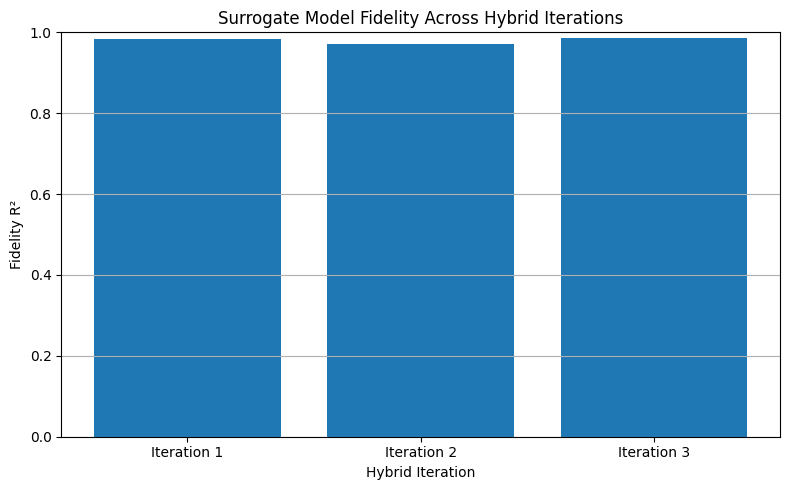

In [24]:
# ------------------------------------------------------------
# 3. Surrogate fidelity chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    surrogate_fidelity_df["Iteration"],
    surrogate_fidelity_df["Fidelity_R2"]
)

plt.title("Surrogate Model Fidelity Across Hybrid Iterations")
plt.xlabel("Hybrid Iteration")
plt.ylabel("Fidelity R²")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/01_Surrogate_Fidelity_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

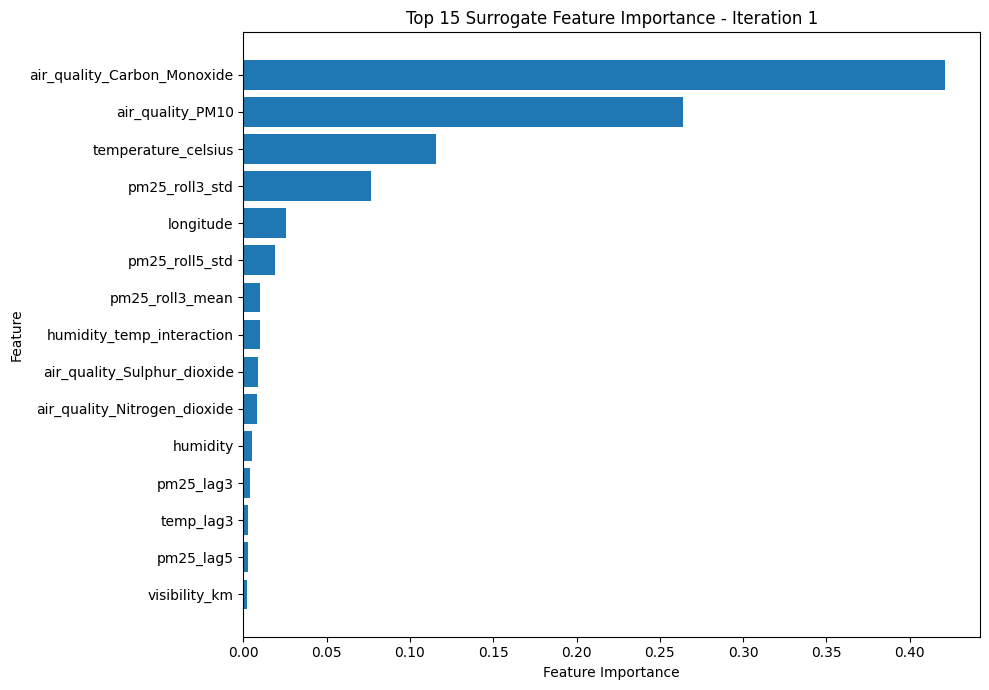

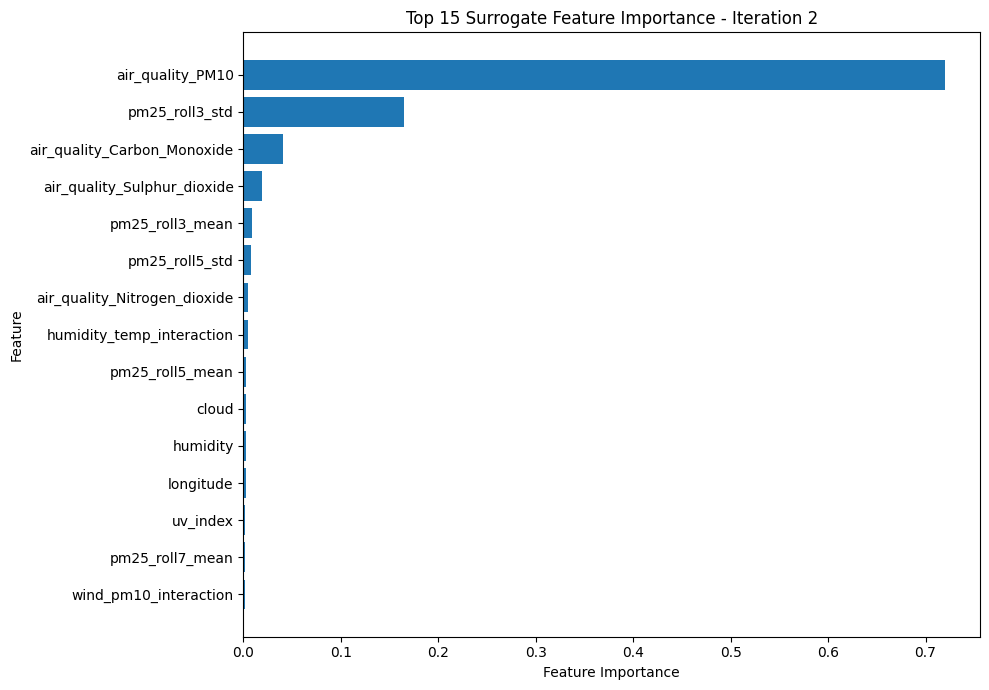

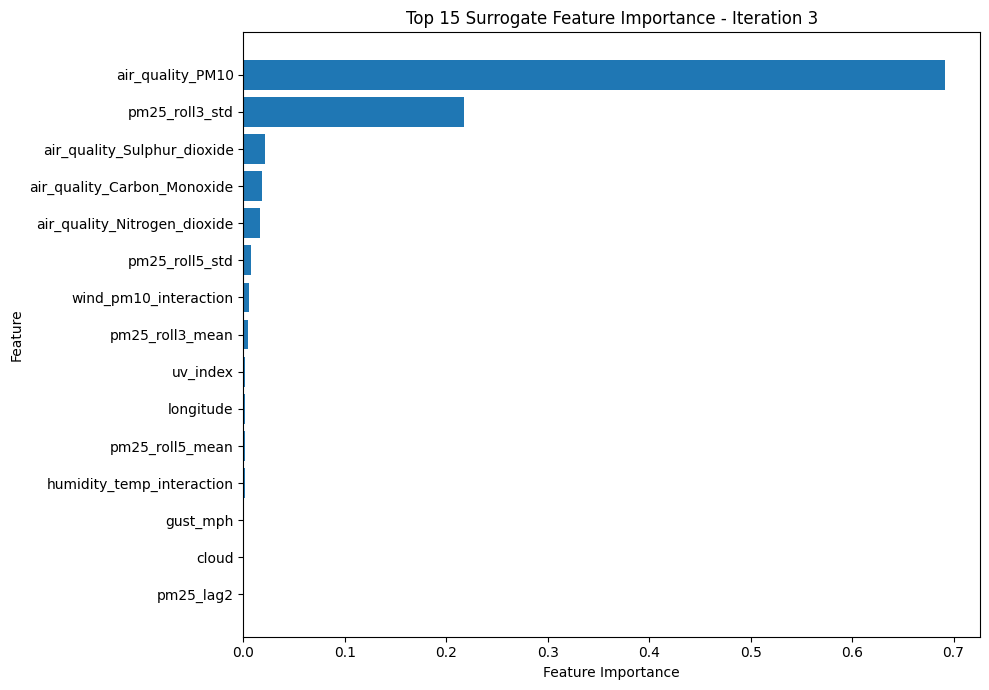

In [25]:
# ------------------------------------------------------------
# 4. Feature importance chart for each iteration
# ------------------------------------------------------------

for iteration_name in surrogate_data.keys():

    fi_iter = feature_importance_df[
        feature_importance_df["Iteration"] == iteration_name
    ].sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 7))

    plt.barh(
        fi_iter["Feature"][::-1],
        fi_iter["Importance"][::-1]
    )

    plt.title(f"Top 15 Surrogate Feature Importance - {iteration_name}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/02_Feature_Importance_{safe_name(iteration_name)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

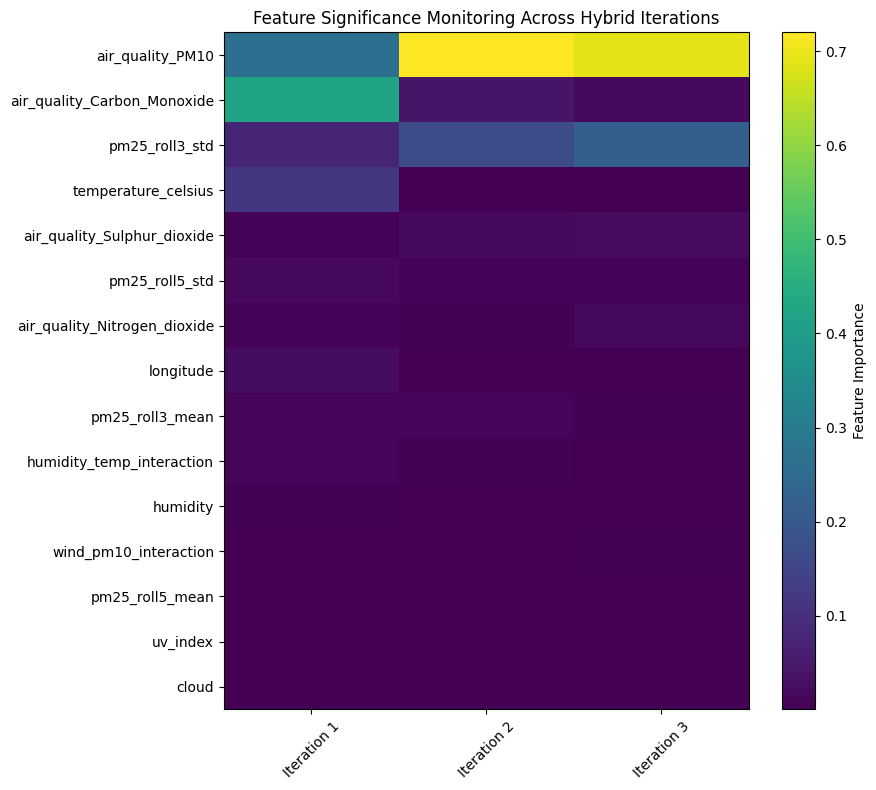

In [26]:
# ------------------------------------------------------------
# 5. Feature significance monitoring heatmap
# ------------------------------------------------------------

top_features = (
    feature_importance_df
    .groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

monitor_df = feature_importance_df[
    feature_importance_df["Feature"].isin(top_features)
].pivot(
    index="Feature",
    columns="Iteration",
    values="Importance"
).fillna(0)

monitor_df = monitor_df.loc[top_features]

monitor_df.to_csv(
    f"{save_dir}/Feature_Significance_Monitoring_Table.csv"
)

plt.figure(figsize=(9, 8))

plt.imshow(monitor_df.values, aspect="auto")

plt.xticks(
    ticks=np.arange(len(monitor_df.columns)),
    labels=monitor_df.columns,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(monitor_df.index)),
    labels=monitor_df.index
)

plt.colorbar(label="Feature Importance")
plt.title("Feature Significance Monitoring Across Hybrid Iterations")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/03_Feature_Significance_Monitoring_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

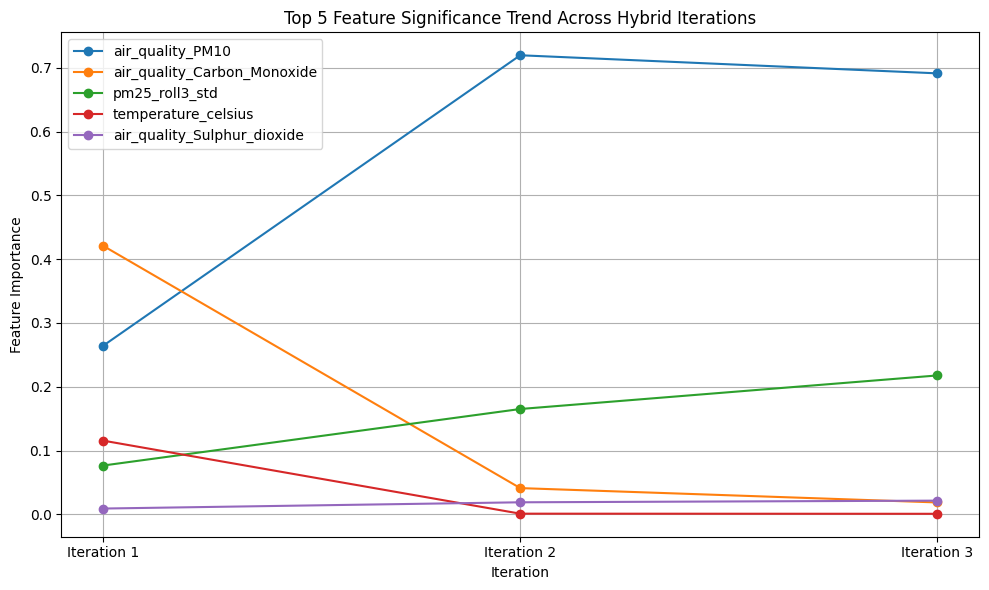

In [27]:
# ------------------------------------------------------------
# 6. Top 5 feature trend across iterations
# ------------------------------------------------------------

top5_features = (
    feature_importance_df
    .groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

trend_df = feature_importance_df[
    feature_importance_df["Feature"].isin(top5_features)
].pivot(
    index="Iteration",
    columns="Feature",
    values="Importance"
).fillna(0)

trend_df.to_csv(
    f"{save_dir}/Top5_Feature_Importance_Trend_Table.csv"
)

plt.figure(figsize=(10, 6))

for feature in top5_features:
    plt.plot(
        trend_df.index,
        trend_df[feature],
        marker="o",
        label=feature
    )

plt.title("Top 5 Feature Significance Trend Across Hybrid Iterations")
plt.xlabel("Iteration")
plt.ylabel("Feature Importance")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/04_Top5_Feature_Importance_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

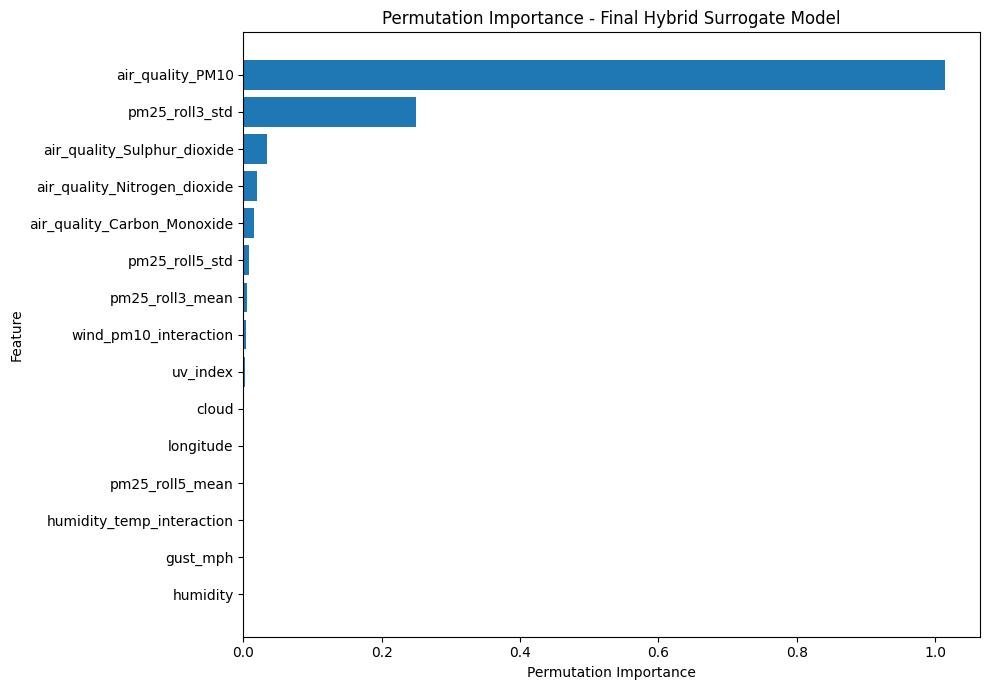

,Feature,Permutation_Importance
0,air_quality_PM10,1.014302
23,pm25_roll3_std,0.249225
3,air_quality_Sulphur_dioxide,0.034272
2,air_quality_Nitrogen_dioxide,0.019031
1,air_quality_Carbon_Monoxide,0.014929
24,pm25_roll5_std,0.007442
20,pm25_roll3_mean,0.005008
32,wind_pm10_interaction,0.004202
10,uv_index,0.001831
5,cloud,0.001259


In [28]:
# ------------------------------------------------------------
# 7. Permutation importance for final surrogate model
# ------------------------------------------------------------

final_iteration = "Iteration 3"

final_surrogate = surrogate_models[final_iteration]["model"]
X_final = surrogate_models[final_iteration]["X_sample"]
y_final = surrogate_models[final_iteration]["y_sample"]

perm_result = permutation_importance(
    final_surrogate,
    X_final,
    y_final,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_final.columns,
    "Permutation_Importance": perm_result.importances_mean
}).sort_values(by="Permutation_Importance", ascending=False)

perm_df.to_csv(
    f"{save_dir}/Final_Iteration_Permutation_Importance.csv",
    index=False
)

top_perm = perm_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["Feature"][::-1],
    top_perm["Permutation_Importance"][::-1]
)

plt.title("Permutation Importance - Final Hybrid Surrogate Model")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/05_Final_Permutation_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

display(perm_df.head(20))

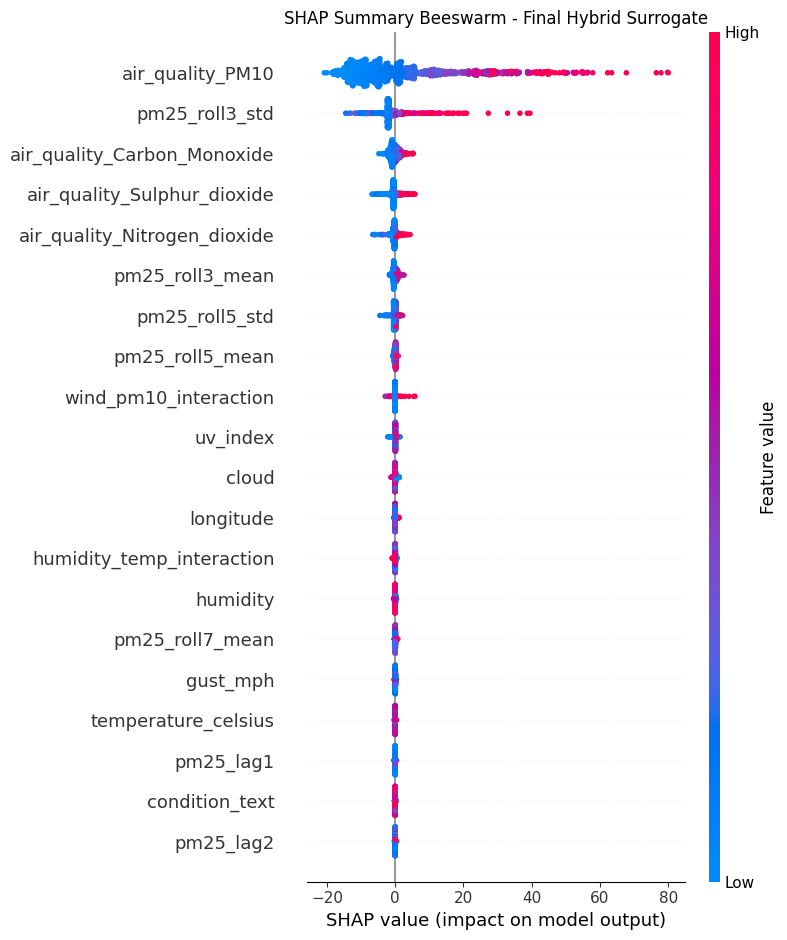

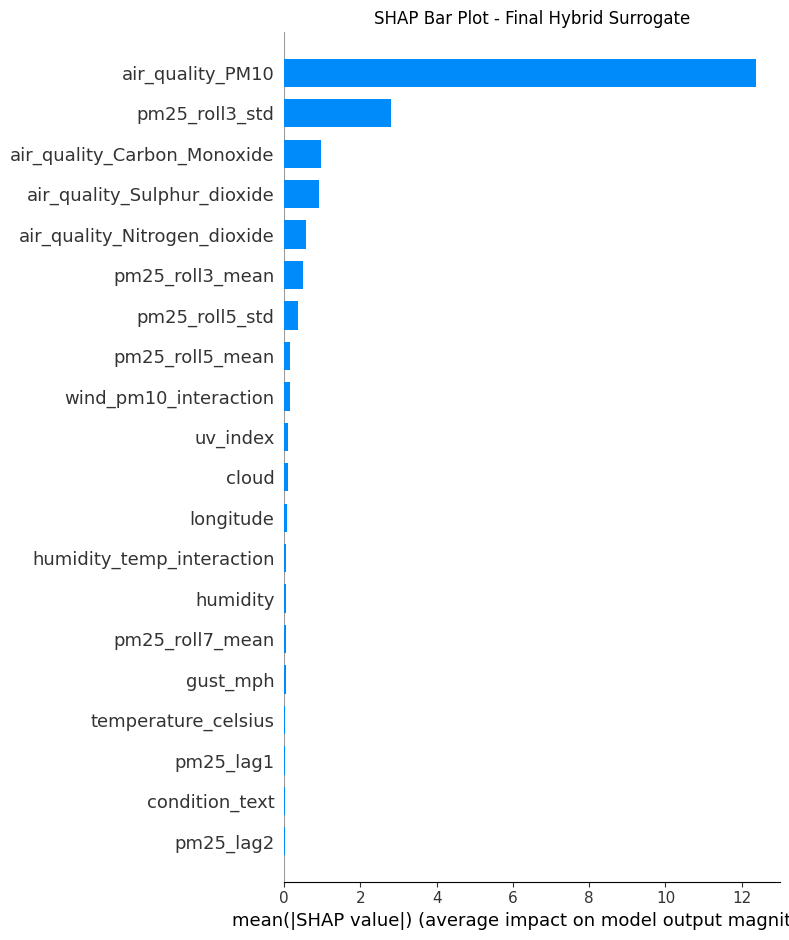

In [29]:
# ------------------------------------------------------------
# 8. SHAP explainability for final surrogate model
# ------------------------------------------------------------

X_shap = X_final.sample(
    min(1000, len(X_final)),
    random_state=42
)

explainer = shap.TreeExplainer(final_surrogate)

shap_values = explainer.shap_values(X_shap)

# SHAP Summary Beeswarm

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    show=False
)

plt.title("SHAP Summary Beeswarm - Final Hybrid Surrogate")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/06_SHAP_Summary_Beeswarm_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# SHAP Bar Plot

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    plot_type="bar",
    show=False
)

plt.title("SHAP Bar Plot - Final Hybrid Surrogate")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/07_SHAP_Bar_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

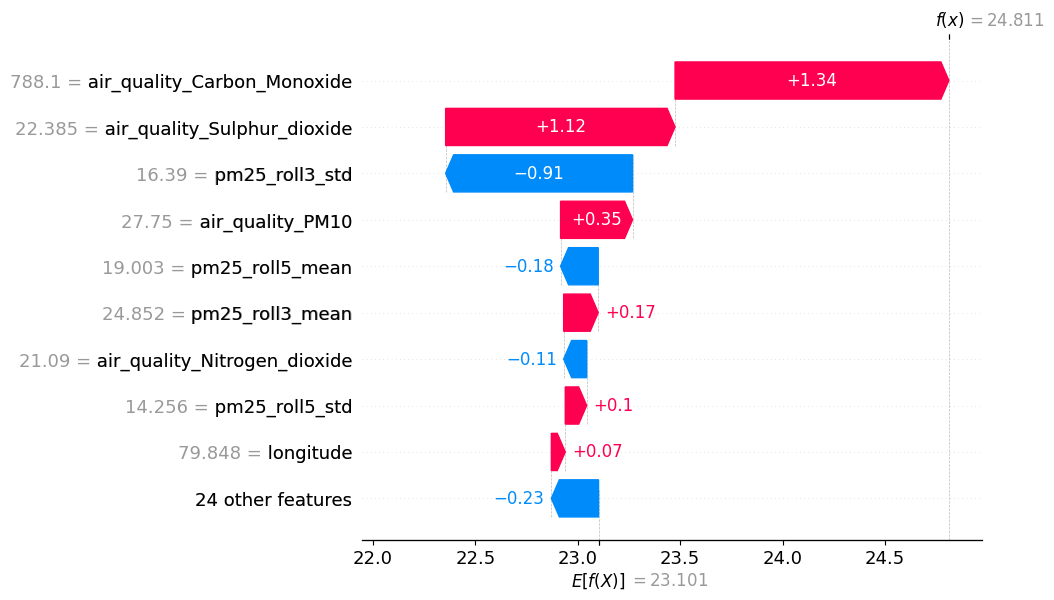

In [30]:
# ------------------------------------------------------------
# 9. SHAP waterfall plot
# ------------------------------------------------------------

sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_shap.iloc[sample_index],
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    explanation,
    show=False
)

plt.savefig(
    f"{save_dir}/08_SHAP_Waterfall_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Top 3 SHAP Features:
['air_quality_PM10', 'pm25_roll3_std', 'air_quality_Carbon_Monoxide']


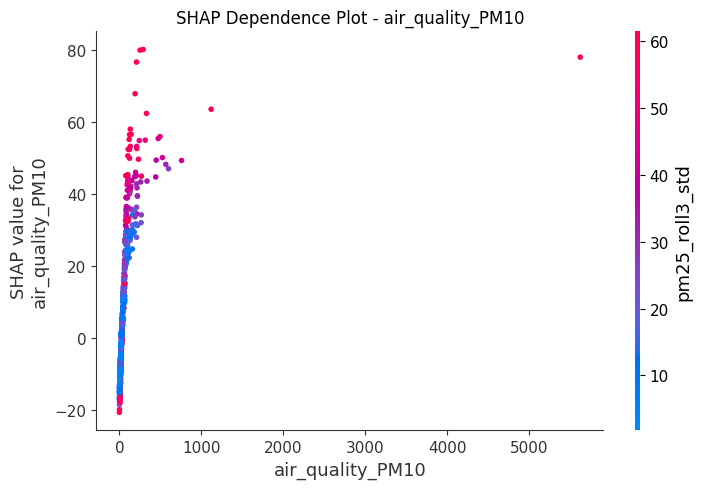

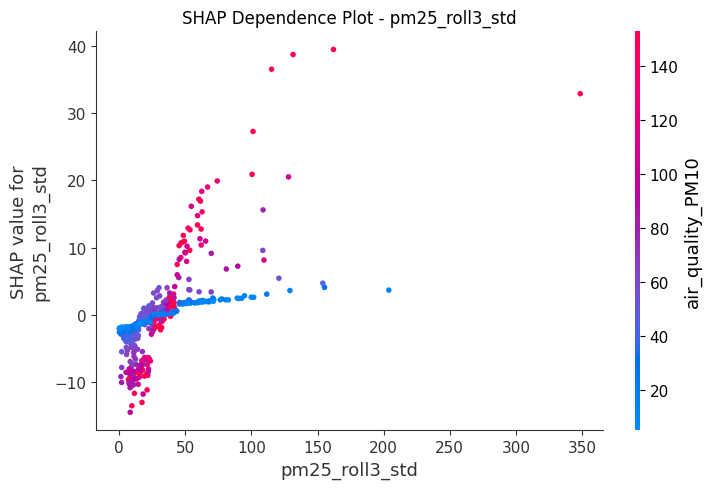

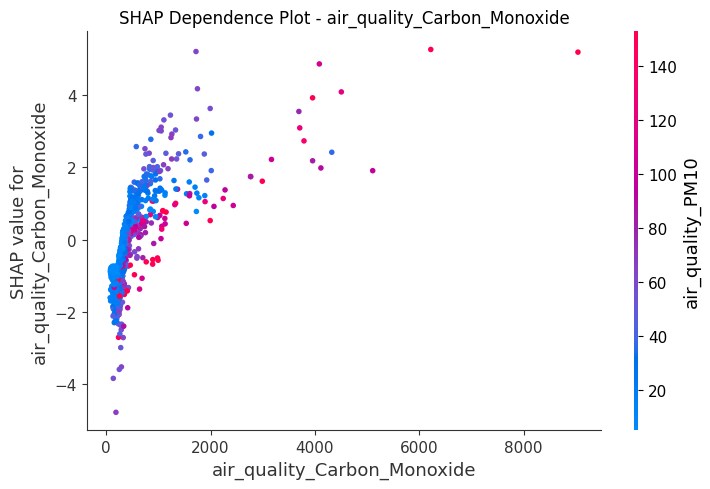

In [31]:
# ------------------------------------------------------------
# 10. SHAP dependence plots for top 3 features
# ------------------------------------------------------------

shap_importance = np.abs(shap_values).mean(axis=0)

top3_shap_features = X_shap.columns[
    np.argsort(shap_importance)[::-1][:3]
]

print("Top 3 SHAP Features:")
print(list(top3_shap_features))

for feature in top3_shap_features:

    shap.dependence_plot(
        feature,
        shap_values,
        X_shap,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/09_SHAP_Dependence_{safe_name(feature)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

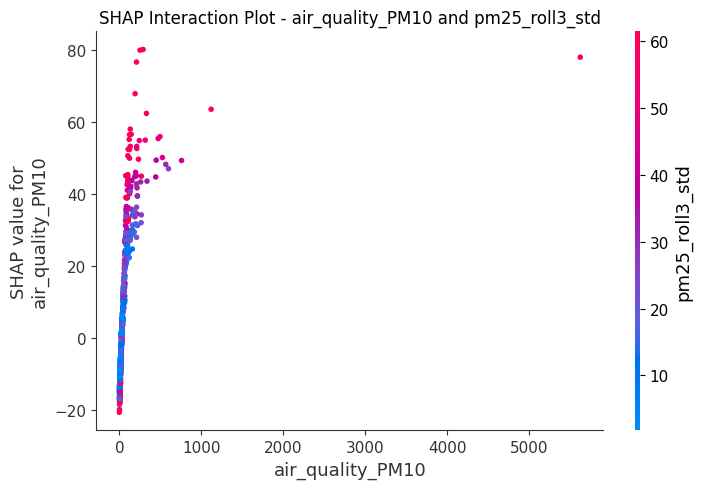

In [32]:
# ------------------------------------------------------------
# 11. SHAP interaction plot
# ------------------------------------------------------------

feature1 = top3_shap_features[0]
feature2 = top3_shap_features[1]

shap.dependence_plot(
    feature1,
    shap_values,
    X_shap,
    interaction_index=feature2,
    show=False
)

plt.title(f"SHAP Interaction Plot - {feature1} and {feature2}")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/10_SHAP_Interaction_{safe_name(feature1)}_{safe_name(feature2)}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

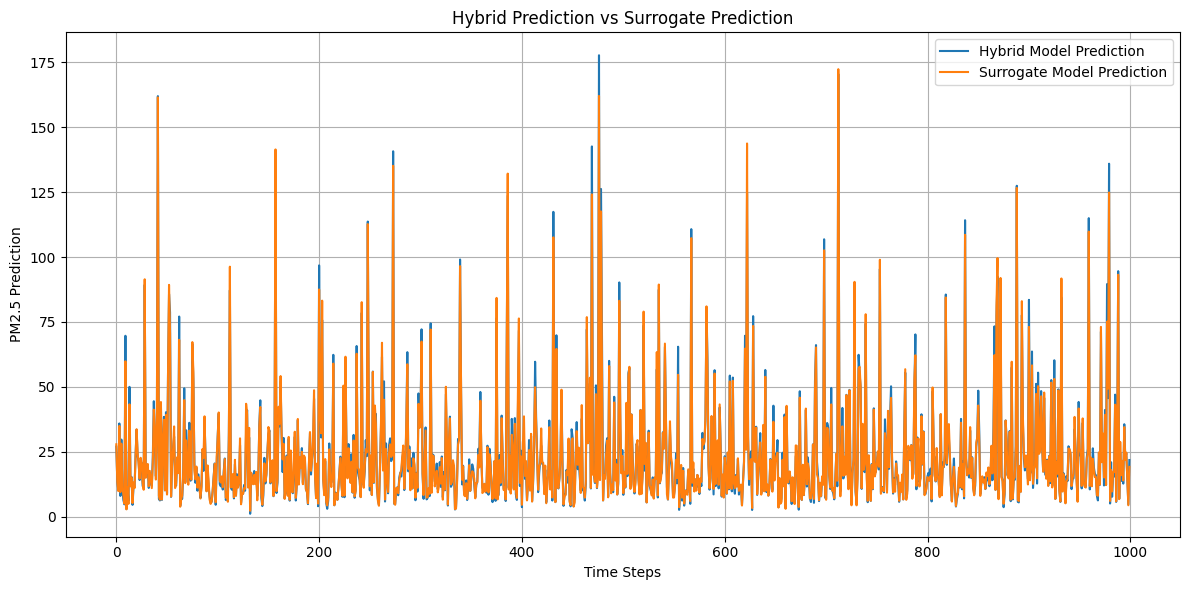

In [33]:
# ------------------------------------------------------------
# 12. Actual hybrid prediction vs surrogate prediction
# ------------------------------------------------------------

y_surrogate_pred = surrogate_models[final_iteration]["surrogate_pred"]

plot_n = min(1000, len(y_final))

plt.figure(figsize=(12, 6))

plt.plot(
    np.array(y_final[:plot_n]),
    label="Hybrid Model Prediction"
)

plt.plot(
    y_surrogate_pred[:plot_n],
    label="Surrogate Model Prediction"
)

plt.title("Hybrid Prediction vs Surrogate Prediction")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5 Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/11_Hybrid_vs_Surrogate_Prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

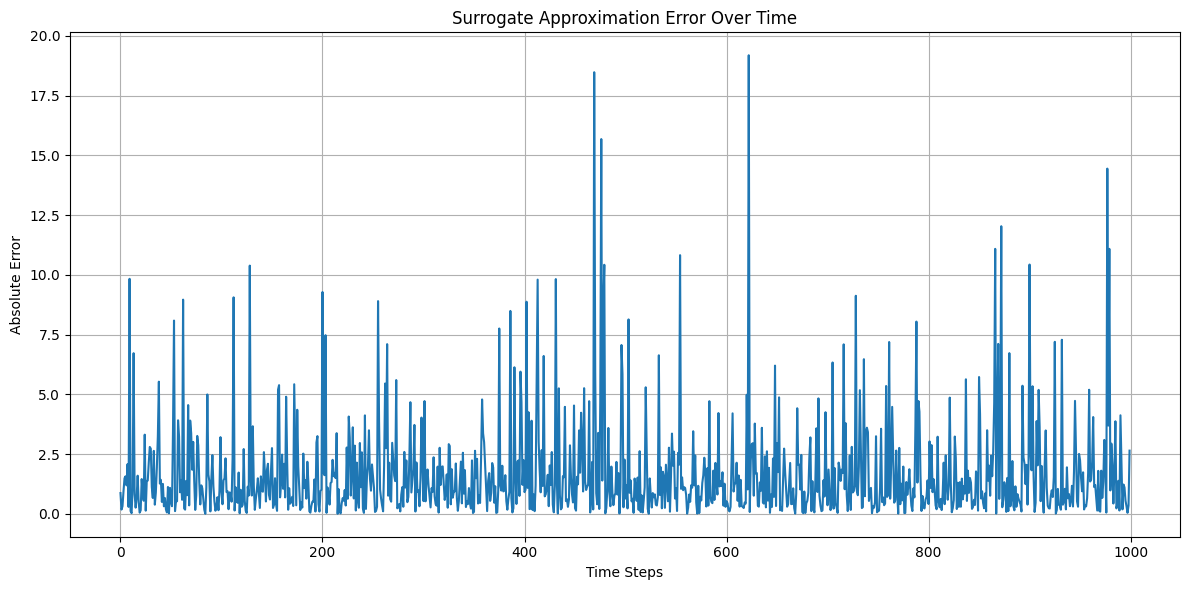

In [34]:
# ------------------------------------------------------------
# 13. Surrogate residual error plot
# ------------------------------------------------------------

surrogate_error = np.abs(np.array(y_final) - y_surrogate_pred)

plt.figure(figsize=(12, 6))

plt.plot(surrogate_error[:plot_n])

plt.title("Surrogate Approximation Error Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/12_Surrogate_Error_Over_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [35]:
# ------------------------------------------------------------
# 14. Download all outputs as ZIP
# ------------------------------------------------------------

zip_path = "/content/Hybrid_Surrogate_XAI_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_list in os.walk(save_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>